 ###nFEMA - Feature Engineering
- Goal:
- Transform clean declarations, public assistance, and disaster summaries
- into modelling-ready features for disaster recovery cost prediction.

####  import libraries

In [83]:
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_theme(style="whitegrid", font_scale=1.2)

DATA_PROCESSED = os.path.join("..", "data", "processed")

declarations = pd.read_csv(os.path.join(DATA_PROCESSED, "declarations_clean.csv"), parse_dates=["declarationdate", "incidentbegindate", "incidentenddate"])
public_assistance = pd.read_csv(os.path.join(DATA_PROCESSED, "public_assistance_clean.csv"))
disaster_summaries= pd.read_csv(os.path.join(DATA_PROCESSED, "disaster_summaries_clean.csv"), parse_dates=["paloaddate", "ialoaddate"]) 

# Reference year
declarations["fydeclared"] = declarations["fydeclared"].fillna(
    declarations["declarationdate"]
)

In [84]:
print(declarations.dtypes)
declarations.head()

disasternumber                       int64
state                               object
declarationtype                     object
incidenttype                        object
declarationdate             datetime64[ns]
incidentbegindate           datetime64[ns]
incidentenddate             datetime64[ns]
fydeclared                           int64
designatedarea                      object
declarationrequestnumber             int64
dtype: object


,disasternumber,state,declarationtype,incidenttype,declarationdate,incidentbegindate,incidentenddate,fydeclared,designatedarea,declarationrequestnumber
0,3610,PR,EM,Severe Storm,2024-08-13,2024-08-13,2024-08-16,2024,Adjuntas (Municipio),24124
1,5529,OR,FM,Fire,2024-08-09,2024-08-08,NaT,2024,Washington (County),24122
2,5528,OR,FM,Fire,2024-08-06,2024-08-04,NaT,2024,Jefferson (County),24116
3,5527,OR,FM,Fire,2024-08-02,2024-08-02,NaT,2024,Deschutes (County),24111
4,3610,PR,EM,Severe Storm,2024-08-13,2024-08-13,2024-08-16,2024,Aguada (Municipio),24124


### Step 1 - Engineered Some Declaration Features

In [85]:
declarations = declarations.copy()

# Step 1a - duration days (how long in days  the disaster lasted)

declarations["disaster_duration_days"] = (
    declarations["incidentenddate"] - declarations["incidentbegindate"]
).dt.days

# step 1b - declaration delay (how long in days it took for a disaster to be declared)

declarations["declaration_delay_days"] = (
    declarations["declarationdate"] - declarations["incidentbegindate"]
).dt.days

# step 1c Clean negative values
declarations["disaster_duration_days"] = declarations["disaster_duration_days"].clip(lower=0)
declarations["declaration_delay_days"] = declarations["declaration_delay_days"].clip(lower=0)

# fill missing values with [0]
declarations["disaster_duration_days"] = declarations["disaster_duration_days"].fillna(0)

# step 1d - seasonality
declarations["declaration_year"] = declarations["declarationdate"].dt.year
declarations["declaration_month"] = declarations["declarationdate"].dt.month
declarations["declaration_quarter"] = declarations["declarationdate"].dt.quarter

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

declarations["declaration_season"] =    declarations["declaration_month"].apply(get_season)


# step 1e - Fiscal year declaration count
declarations["fy_declaration_count"] = (
    declarations.groupby("fydeclared")["disasternumber"]
    .transform("count")
)

In [86]:
# step 1f - Aggregate some declaration dataset to derive more features

agg_features = (
    declarations.groupby("disasternumber")
    .agg(

        # agregarted features
        avg_duration_days=("disaster_duration_days", "mean"),
        avg_delay_days=("declaration_delay_days", "mean")
    ).round(2).reset_index()
)

### Step 2-  Interaction Features

In [87]:
# step 2a - Total declarations per state 

declarations["state_declaration_count"] = (
    declarations.groupby("state")["disasternumber"]
    .transform("count")
)

# step 2b - Incident frequency

declarations["incident_frequency"] = (
    declarations.groupby("incidenttype")["disasternumber"]
    .transform("count")
)


# step 2c -  State × Incident Type frequency

declarations["state_incident_count"] = (
    declarations.groupby(
        ["state", "incidenttype"]
    )["disasternumber"]
    .transform("count")
)


# step 2d - State × Fiscal Year declarations

declarations["state_year_count"] = (
    declarations.groupby(
        ["state", "fydeclared"]
    )["disasternumber"]
    .transform("count")
)

In [88]:
# step 2e- drop date columns
declarations.drop(
    columns=[
    "declarationdate",
    "incidentbegindate",
    "incidentenddate"
],
inplace=True
)

# step 2f - merge engineered features
declaration_features = declarations.merge(
    agg_features,
    how="left",
    on="disasternumber"
)

### Step 3 Engineer Public Assistance Features

In [89]:
print(public_assistance.dtypes)
public_assistance.head()


disasternumber             int64
stateabbreviation         object
projectamount            float64
federalshareobligated    float64
totalobligated           float64
projectsize               object
damagecategorycode        object
applicationtitle          object
dtype: object


,disasternumber,stateabbreviation,projectamount,federalshareobligated,totalobligated,projectsize,damagecategorycode,applicationtitle
0,1361,WA,1203.00,902.25,957.10,Small,B,(PW# 81) INSPECTION OF TOWN BUILDINGS & UTILITIES
1,1603,LA,15156787.07,15156787.07,15312129.35,Large,E,(PW# 18773) CONTENTS ROLLUP-MULTIPLE SITES; MU...
2,3582,MS,159127.24,119345.43,119345.43,Small,B,MS- State Department of Health EPM-Period 1 - ...
3,1817,WA,6847.49,5135.62,5135.62,Small,C,(PW# 537) SEBC005 - S. Emery Ave. Road/Shoulde...
4,3582,MS,118703.32,89027.49,89027.49,Small,B,MS- State Department of Health EPM-Period 3 - ...


In [90]:
# Step 4a - Public Assistance Feature Engineering

pa_features = (
    public_assistance.groupby("disasternumber")
    .agg(
        # Step 4a - Project amount
        pa_project_count=("projectamount", "count"),
        pa_project_amount_total=("projectamount", "sum"),
        pa_project_amount_mean=("projectamount", "mean"),

        # Step 4b - Federal share obligated
        pa_obligated_total=("federalshareobligated", "sum"),
        pa_obligated_mean=("federalshareobligated", "mean"),
        pa_obligated_max=("federalshareobligated", "max"),
    )
    .reset_index()
)

# Step 4c - Project size thresholds
large_threshold = public_assistance["projectamount"].quantile(0.75)
small_threshold = public_assistance["projectamount"].quantile(0.25)

pa_features["large_project_count"] = (
    public_assistance[public_assistance["projectamount"] >= large_threshold]
    .groupby("disasternumber")
    .size()
    .reindex(pa_features["disasternumber"])
    .fillna(0)
    .values
)

pa_features["small_project_count"] = (
    public_assistance[public_assistance["projectamount"] <= small_threshold]
    .groupby("disasternumber")
    .size()
    .reindex(pa_features["disasternumber"])
    .fillna(0)
    .values
)

# Step 4d - Ratio and interaction features
pa_features["avg_obligation_per_project"] = (
    pa_features["pa_obligated_total"] / (pa_features["pa_project_count"] + 1)
)

pa_features["funding_intensity"] = (
    pa_features["pa_obligated_total"] / (pa_features["pa_project_amount_total"] + 1)
)

pa_features["large_project_ratio"] = (
    pa_features["large_project_count"] / (pa_features["pa_project_count"] + 1)
)

pa_features["small_project_ratio"] = (
    pa_features["small_project_count"] / (pa_features["pa_project_count"] + 1)
)

pa_features = pa_features.fillna(0)

pa_features.head()

,disasternumber,pa_project_count,pa_project_amount_total,pa_project_amount_mean,pa_obligated_total,pa_obligated_mean,pa_obligated_max,large_project_count,small_project_count,avg_obligation_per_project,funding_intensity,large_project_ratio,small_project_ratio
0,1239,276,10600492.88,38407.582899,7950369.84,28805.687826,1309005.45,34.0,67.0,28701.696173,0.750000,0.122744,0.241877
1,1257,1760,42972184.44,24416.013886,32229051.37,18311.961006,804284.00,118.0,634.0,18301.562391,0.749998,0.067007,0.360023
2,1260,212,12948267.66,61076.734245,9711200.82,45807.551038,687414.68,39.0,60.0,45592.492113,0.750000,0.183099,0.281690
3,1261,138,7331674.17,53128.073696,5498755.69,39846.055725,772826.25,30.0,48.0,39559.393453,0.750000,0.215827,0.345324
4,1262,268,19964936.88,74496.033134,14973702.82,55872.025448,3104475.92,56.0,89.0,55664.322751,0.750000,0.208178,0.330855


In [91]:
# step 4e - Select only the columns needed for merging

pa_merge = (
    public_assistance.groupby("disasternumber", as_index=False)
    .agg(
        totalobligated=("totalobligated", "sum")
    )
)

# Log transform the target variable

pa_merge["log_totalobligated"] = np.log1p(pa_merge["totalobligated"])

pa_merge.head()

,disasternumber,totalobligated,log_totalobligated
0,1239,8224551.92,15.922634
1,1257,33271088.84,17.320199
2,1260,10096131.65,16.127663
3,1261,5735788.22,15.562236
4,1262,15408228.37,16.550412


### step 5 - Engineer Disaster Summaries Features

In [92]:
print(disaster_summaries.dtypes)
disaster_summaries.head()

disasternumber                         int64
totalnumberiaapproved                float64
totalamountihpapproved               float64
totalamounthaapproved                float64
totalamountonaapproved               float64
totalobligatedamountpa               float64
totalobligatedamountcatab            float64
totalobligatedamountcatc2g           float64
totalobligatedamounthmgp             float64
paloaddate                    datetime64[ns]
ialoaddate                    datetime64[ns]
dtype: object


,disasternumber,totalnumberiaapproved,totalamountihpapproved,totalamounthaapproved,totalamountonaapproved,totalobligatedamountpa,totalobligatedamountcatab,totalobligatedamountcatc2g,totalobligatedamounthmgp,paloaddate,ialoaddate
0,1971,16375.0,77097372.06,57302364.20,19795007.86,2.010424e+08,1.271363e+08,6.708809e+07,63346282.14,2026-02-06,2026-05-26
1,4420,3428.0,27279186.25,24356998.74,2922187.51,5.294109e+08,5.027339e+07,4.440429e+08,38797583.91,2026-05-26,2026-05-26
2,4531,5577.0,37357961.48,0.00,37357961.48,5.647922e+08,5.605798e+08,0.000000e+00,15288527.33,2026-05-26,2026-05-26
3,4534,1940.0,10616929.18,0.00,10616929.18,2.256010e+08,2.249514e+08,0.000000e+00,1463754.80,2026-05-26,2026-05-26
4,1925,1624.0,10602928.54,9705873.50,897055.04,5.930566e+06,1.577961e+06,4.144901e+06,2821027.04,2026-02-06,2026-05-26


In [94]:
# Step 5a  - Disaster Summaries Feature Engineering

ds_features = (
    disaster_summaries.groupby("disasternumber")
    .agg(
        ia_approved_count=("totalnumberiaapproved", "sum"),
        ihp_amount=("totalamountihpapproved", "sum"),
        ona_amount=("totalamountonaapproved", "sum"),
        pa_amount=("totalobligatedamountpa", "sum"),
    )
    .reset_index()
)

In [95]:
# step 5b - Ratio and interaction features

# Total assistance
ds_features["total_assistance"] = (
    ds_features["ihp_amount"] +
    ds_features["ona_amount"] +
    ds_features["pa_amount"]
)

# Ratios
ds_features["ihp_ratio"] = (
    ds_features["ihp_amount"] /
    (ds_features["total_assistance"] + 1)
)

ds_features["ona_ratio"] = (
    ds_features["ona_amount"] /
    (ds_features["total_assistance"] + 1)
)

ds_features["pa_ratio"] = (
    ds_features["pa_amount"] /
    (ds_features["total_assistance"] + 1)
)

# Interaction feature
ds_features["assistance_per_approved"] = (
    ds_features["total_assistance"] /
    (ds_features["ia_approved_count"] + 1)
)

ds_features = ds_features.fillna(0)

ds_features.head()

,disasternumber,ia_approved_count,ihp_amount,ona_amount,pa_amount,total_assistance,ihp_ratio,ona_ratio,pa_ratio,assistance_per_approved
0,1440,272.0,470371.72,94183.06,18277293.72,18841848.50,0.024964,0.004999,0.970037,69017.760073
1,1441,412.0,1880461.20,1138536.23,3202892.95,6221890.38,0.302233,0.182989,0.514778,15065.109879
2,1442,530.0,3306085.11,1759227.03,12603404.04,17668716.18,0.187115,0.099567,0.713317,33274.418418
3,1443,555.0,2028548.78,1388094.42,20182808.77,23599451.97,0.085957,0.058819,0.855224,42445.057500
4,1445,199.0,509173.67,48102.72,8721045.16,9278321.55,0.054878,0.005184,0.939938,46391.607750


### STEP 6 - Merge All Feature Tables


In [96]:
# Remove duplicate disaster numbers in declarations merge table
declaration_features = declaration_features.drop_duplicates(
    subset=["disasternumber"]
)

# Remove duplicate disaster numbers in Public Assistance merge table
pa_merge = pa_merge.drop_duplicates(subset="disasternumber")


features_fema = (
    declaration_features
    .merge(pa_merge, on="disasternumber", how="left")
   )

features_fema = features_fema.fillna(0)

print(features_fema.shape)
features_fema.head()


(5184, 22)


,disasternumber,state,declarationtype,incidenttype,fydeclared,designatedarea,declarationrequestnumber,disaster_duration_days,declaration_delay_days,declaration_year,...,declaration_season,fy_declaration_count,state_declaration_count,incident_frequency,state_incident_count,state_year_count,avg_duration_days,avg_delay_days,totalobligated,log_totalobligated
0,3610,PR,EM,Severe Storm,2024,Adjuntas (Municipio),24124,3.0,0,2024,...,Summer,2147,2116,19308,380,91,3.0,0.0,0.00,0.000000
1,5529,OR,FM,Fire,2024,Washington (County),24122,0.0,1,2024,...,Summer,2147,646,3876,180,33,0.0,1.0,0.00,0.000000
2,5528,OR,FM,Fire,2024,Jefferson (County),24116,0.0,2,2024,...,Summer,2147,646,3876,180,33,0.0,2.0,0.00,0.000000
3,5527,OR,FM,Fire,2024,Deschutes (County),24111,0.0,0,2024,...,Summer,2147,646,3876,180,33,0.0,0.0,0.00,0.000000
4,4312,CA,DR,Severe Storm,2017,Resighini Rancheria (Indian Reservation),17035,3.0,83,2017,...,Spring,1835,1689,19308,384,115,3.0,83.0,269934.77,12.505939


### step 7 - Correlation (Numeric Features)

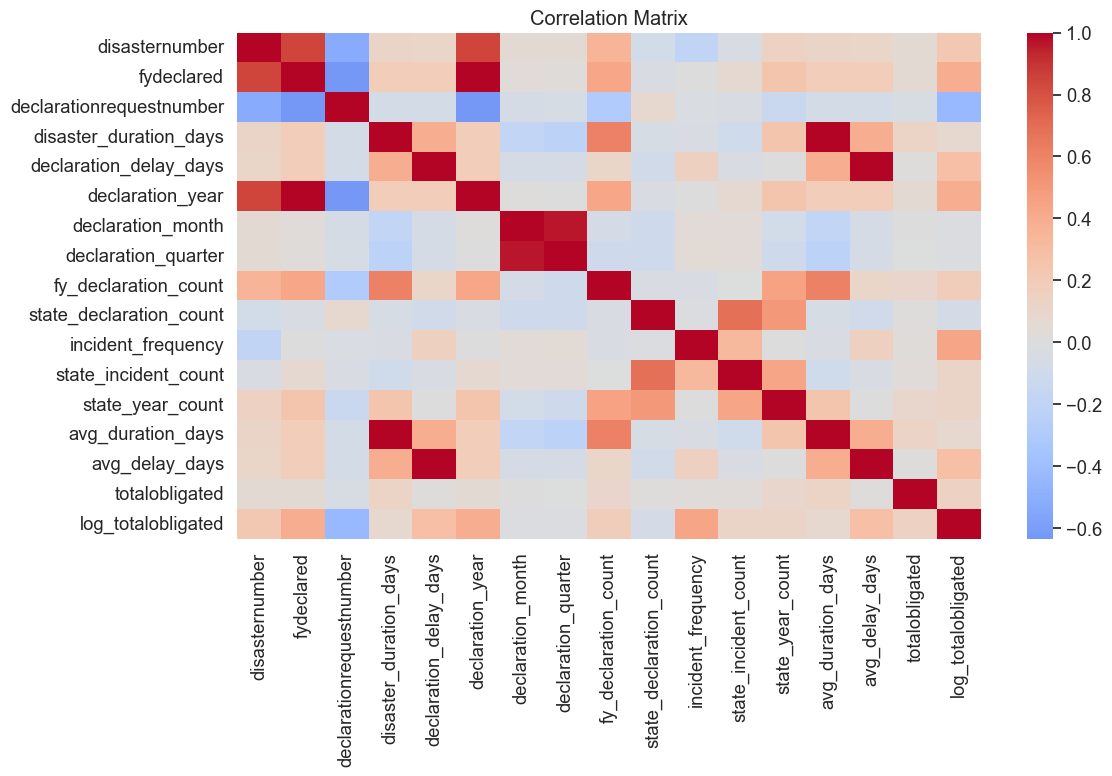

In [97]:
plt.figure(figsize=(12,8))

sns.heatmap(
    features_fema.select_dtypes(include="number").corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

### Step 8 - Correlation Signal Check


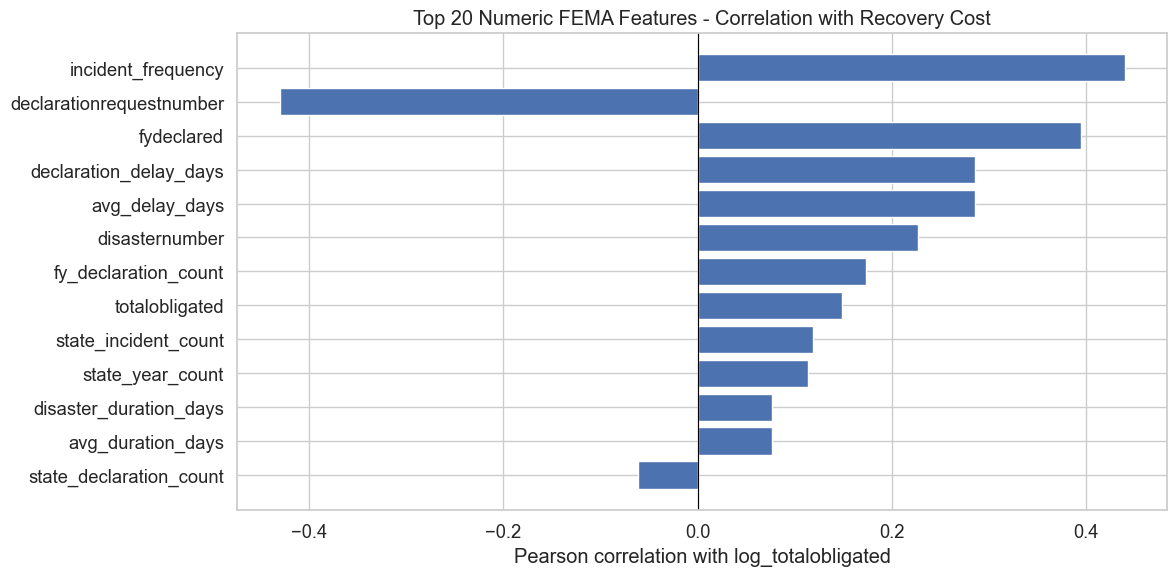

In [98]:
target = "log_totalobligated"

numeric_corr_df = features_fema.select_dtypes(
    include=["int64", "float64", "bool"]
)

corr = (
    numeric_corr_df
    .corr()[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
)

corr.head(20)


#- plot matrix 

fig, ax = plt.subplots(figsize=(12, 6))

top20 = corr.head(20)

ax.barh(top20.index[::-1], top20.values[::-1])
ax.axvline(0, color="black", linewidth=0.8)

ax.set(
    title="Top 20 Numeric FEMA Features - Correlation with Recovery Cost",
    xlabel="Pearson correlation with log_totalobligated"
)

plt.tight_layout()
plt.show()

### Step 9 -  Save Final Feature Matrix


In [99]:
DATA_PROCESSED = os.path.join("..", "data", "processed")
os.makedirs(DATA_PROCESSED, exist_ok=True)

features_fema.to_csv(
    os.path.join(DATA_PROCESSED, "features_fema.csv"),
    index=False
)

print(" Feature matrix saved successfully.")
print(features_fema.shape)
features_fema.head()

 Feature matrix saved successfully.
(5184, 22)


,disasternumber,state,declarationtype,incidenttype,fydeclared,designatedarea,declarationrequestnumber,disaster_duration_days,declaration_delay_days,declaration_year,...,declaration_season,fy_declaration_count,state_declaration_count,incident_frequency,state_incident_count,state_year_count,avg_duration_days,avg_delay_days,totalobligated,log_totalobligated
0,3610,PR,EM,Severe Storm,2024,Adjuntas (Municipio),24124,3.0,0,2024,...,Summer,2147,2116,19308,380,91,3.0,0.0,0.00,0.000000
1,5529,OR,FM,Fire,2024,Washington (County),24122,0.0,1,2024,...,Summer,2147,646,3876,180,33,0.0,1.0,0.00,0.000000
2,5528,OR,FM,Fire,2024,Jefferson (County),24116,0.0,2,2024,...,Summer,2147,646,3876,180,33,0.0,2.0,0.00,0.000000
3,5527,OR,FM,Fire,2024,Deschutes (County),24111,0.0,0,2024,...,Summer,2147,646,3876,180,33,0.0,0.0,0.00,0.000000
4,4312,CA,DR,Severe Storm,2017,Resighini Rancheria (Indian Reservation),17035,3.0,83,2017,...,Spring,1835,1689,19308,384,115,3.0,83.0,269934.77,12.505939
